# Violence Detection — Experimentation Notebook

Binary (violent / non-violent) video classification on RWF-2000. This notebook is for experimentation, visualisation, debugging and analysis; all production logic lives in the `.py` modules and is imported here, never duplicated.

## 1. Project setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/violence_detection"  # edit if you cloned/uploaded elsewhere
    if not os.path.exists(PROJECT_ROOT):
        raise FileNotFoundError(
            "Clone or upload the project to this path first, e.g.:\n"
            "  !git clone <this-repo> /content/violence_detection\n"
            "or edit PROJECT_ROOT above to match where you placed it."
        )
else:
    PROJECT_ROOT = os.path.abspath("")

sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /home/pp26/violence_detection/violence_detection


## 2. Imports

In [2]:
import json

import numpy as np
import matplotlib.pyplot as plt
import torch

from config.config import Config, get_default_config
from data.splits import build_sample_lists
from data.dataset import RWFVideoDataset
from data.transforms import ClipTrainTransform, ClipEvalTransform, IMAGENET_MEAN, IMAGENET_STD
from data.dataloaders import build_dataloaders
from models.build import build_model
from training.trainer import Trainer
from training.metrics import compute_binary_metrics, find_threshold_for_recall
from utils.seed import set_seed
from utils.device import get_device
from utils.model_utils import count_parameters
from utils.checkpoint import load_checkpoint
from utils.history import load_history, plot_training_curves, plot_comparison
from inference.predict import ViolenceDetector
from evaluate import run_evaluation

## 3. Configuration

Sections 4-11 below walk through the pipeline step by step for a single, default configuration (`ARCHITECTURE`), to inspect data and a freshly-built model up close. Section 12 then trains a **list of named experiments** - as many configurations as you want, on either architecture - back to back for comparison.

**Note on batch size:** `get_default_config` returns the batch sizes this project was tuned with on a 16GB GPU (32 for `lightweight_tsm`, 8 for `backbone_transformer`). This walkthrough overrides them to a small value so it stays fast and works on any machine, including a CPU-only laptop - depthwise-separable convolutions (used throughout `lightweight_tsm`) are notably memory-hungry in PyTorch's CPU backend (a PyTorch/CPU characteristic, not specific to this model). Section 12's experiments use whatever batch size each experiment's configuration function sets.

In [3]:
ARCHITECTURE = "lightweight_tsm"  # or "backbone_transformer"

config = get_default_config(ARCHITECTURE)
config.data.data_root = "./data/RWF-2000"  # point this at your extracted dataset
config.training.num_epochs = 5  # keep small for interactive experimentation; raise for a real run
config.training.batch_size = 4  # small and fast for this walkthrough; see note above

# Multiprocessing DataLoader workers fork after the Jupyter kernel has already
# started, which can crash the kernel. Scripts (train.py) don't have this
# restriction and can safely use config.data.num_workers > 0.
config.data.num_workers = 0

print(json.dumps(config.to_dict(), indent=2))

{
  "data": {
    "data_root": "./data/RWF-2000",
    "train_dir": "train",
    "val_dir": "val",
    "class_names": [
      "NonFight",
      "Fight"
    ],
    "num_frames": 16,
    "frame_size": 112,
    "val_ratio": 0.1,
    "num_workers": 0,
    "pin_memory": true
  },
  "model": {
    "architecture": "lightweight_tsm",
    "pretrained": false,
    "freeze_backbone_epochs": 5,
    "unfreeze_num_stages": 2,
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 4,
    "ff_dim": 1024,
    "transformer_dropout": 0.1,
    "width_mult": 1.0,
    "classifier_dropout": 0.3
  },
  "training": {
    "seed": 42,
    "batch_size": 4,
    "num_epochs": 5,
    "optimizer": "sgd",
    "learning_rate": 0.05,
    "backbone_learning_rate": 1e-05,
    "weight_decay": 5e-05,
    "warmup_ratio": 0.05,
    "grad_clip_norm": 1.0,
    "loss": "bce",
    "focal_gamma": 2.0,
    "focal_alpha": 0.25,
    "mixed_precision": true,
    "early_stopping_patience": 8,
    "monitor_metric": "f1",
    "decision_thr

## 4. Random seeds

In [4]:
config.training.seed=26
set_seed(config.training.seed)
print(f"Seeded Python/NumPy/PyTorch with seed={config.training.seed}")

Seeded Python/NumPy/PyTorch with seed=26


## 5. Dataset inspection

In [5]:
train_samples, val_samples, test_samples = build_sample_lists(config.data, config.training.seed)
print(f"train: {len(train_samples)}  val: {len(val_samples)}  test: {len(test_samples)}")

train: 1440  val: 160  test: 400


## 6. Exploratory data analysis

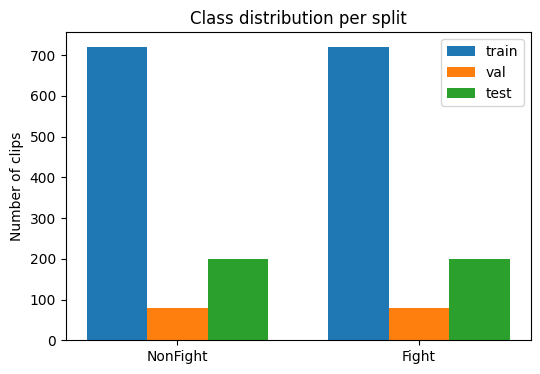

In [6]:
def class_counts(samples):
    counts = [0, 0]
    for _, label in samples:
        counts[label] += 1
    return counts

splits = {"train": train_samples, "val": val_samples, "test": test_samples}
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.25
for i, (name, samples) in enumerate(splits.items()):
    counts = class_counts(samples)
    ax.bar(np.arange(2) + i * width, counts, width=width, label=name)
ax.set_xticks(np.arange(2) + width)
ax.set_xticklabels(config.data.class_names)
ax.set_ylabel("Number of clips")
ax.set_title("Class distribution per split")
ax.legend()
plt.show()

## 7. Data preprocessing

In [7]:
train_transform = ClipTrainTransform(config.data.frame_size)
eval_transform = ClipEvalTransform(config.data.frame_size)
print("Train transform resize/crop size:", config.data.frame_size)

Train transform resize/crop size: 112


## 8. Sample visualization

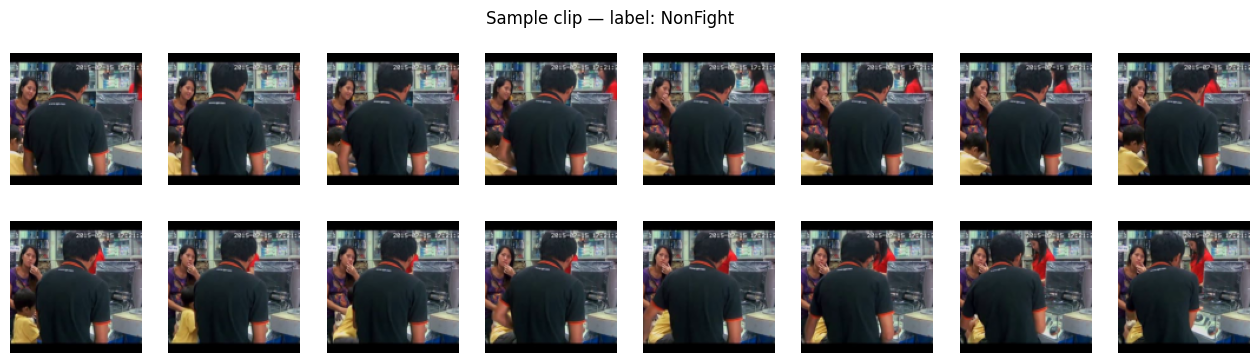

In [8]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

preview_dataset = RWFVideoDataset([train_samples[0]], config.data.num_frames, eval_transform, train=False)
clip_tensor, label = preview_dataset[0]

n_cols = min(8, config.data.num_frames)
n_rows = max(1, config.data.num_frames // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
for i, ax in enumerate(np.array(axes).flat):
    frame = (clip_tensor[i] * std + mean).clamp(0, 1)
    ax.imshow(frame.permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle(f"Sample clip — label: {config.data.class_names[int(label)]}")
plt.show()

## 9. Dataset and DataLoader creation

In [9]:
train_loader, val_loader, test_loader = build_dataloaders(config)
clips, labels = next(iter(train_loader))
print("Batch clip shape:", clips.shape, "| labels shape:", labels.shape)

Batch clip shape: torch.Size([4, 16, 3, 112, 112]) | labels shape: torch.Size([4])


## 10. Model definition / import

In [10]:
model = build_model(config)
print(model.__class__.__name__)

LightweightTSMNet


## 11. Model summary

In [11]:
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(model)

Total parameters: 1,924,287
Trainable parameters: 1,924,287
LightweightTSMNet(
  (stem): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (stages): Sequential(
    (0): InvertedResidualBlock(
      (temporal_shift): TemporalShift()
      (expand_and_depthwise): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (se): Identity()
      (project): Sequential(
        (0): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): InvertedResidualBlock(
      (temporal_shift): TemporalShift()
      (expa

## 12. Training

Define as many **named experiments** as you like below - each entry is `(name, architecture, configure_fn)`, where `configure_fn(run_config)` mutates a fresh, fully-default config for that architecture. Every experiment gets its own `experiment_name` (so its checkpoints/logs never collide with another experiment's, even two experiments on the same architecture), and each one is trained, in sequence, to completion before the next one starts.

This is *not* "apply change A, then also apply change B to the same run" - each named entry below produces one independent, from-scratch training run with its own config. To compare, say, two learning rates, give them two separate entries.

The three entries below reproduce the configurations discussed for this project: two `lightweight_tsm` variants and a regularised `backbone_transformer` variant. Add, remove, or edit entries freely.

In [12]:
# def configure_lightweight_run1(run_config):
#     run_config.training.monitor_metric = "roc_auc" #
#     run_config.training.num_epochs = 50
#     run_config.training.batch_size = 32
#     run_config.training.early_stopping_patience = 10 #
#     run_config.data.num_workers = 1

def configure_lightweight_run1(run_config):
    run_config.data.num_frames = 24          # was 16 - more temporal coverage per clip
    run_config.training.monitor_metric = "roc_auc"
    run_config.training.num_epochs = 50
    run_config.training.batch_size = 24      # reduced from 32; batch×frames ≈ same VRAM load as before
    run_config.training.early_stopping_patience = 10
    run_config.data.num_workers = 0
    run_config.training.seed = 26 
# def configure_lightweight_run2(run_config):
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.learning_rate = 0.11
#     run_config.training.weight_decay  = 1e-05 #
#     run_config.training.warmup_ratio = 0.1 #
#     run_config.training.num_epochs = 50
#     run_config.training.batch_size = 70
#     run_config.training.early_stopping_patience = 10 #
#     run_config.data.num_workers = 1

# def configure_lightweight_run2(run_config):
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.learning_rate = 0.075   # sqrt-scaling rule: 0.05×√(70/32)≈0.074, gentler than the 0.11 linear-scaled value
#     run_config.training.weight_decay = 3e-5     # midpoint between the too-loose 1e-5 and the spike-causing 5e-5
#     run_config.training.warmup_ratio = 0.1      # keep - this is what actually killed the spikes
#     run_config.training.num_epochs = 70         # batch=70 gets <half the steps/epoch of batch=32; more epochs compensates
#     run_config.training.batch_size = 70
#     run_config.training.early_stopping_patience = 12
#     run_config.data.num_workers = 0


# def configure_backbone_run1(run_config):
#     run_config.model.unfreeze_num_stages = 1
#     run_config.model.transformer_dropout = 0.3 
#     run_config.model.classifier_dropout = 0.4 
#     run_config.model.freeze_backbone_epochs = 8
#     run_config.training.weight_decay = 5e-4
#     run_config.training.backbone_learning_rate = 5e-6 
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.num_epochs = 25
#     run_config.training.batch_size = 15 
#     run_config.data.num_workers = 1

# def configure_backbone_run2(run_config):
#     run_config.model.unfreeze_num_stages = 1
#     run_config.model.transformer_dropout = 0.4 #0.2
#     run_config.model.classifier_dropout = 0.5 # 0.4
#     run_config.model.freeze_backbone_epochs = 8
#     run_config.training.weight_decay = 5e-4
#     run_config.training.backbone_learning_rate = 5e-6 
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.num_epochs = 25
#     run_config.training.batch_size = 25 
#     run_config.data.num_workers = 1

def configure_backbone_run2(run_config):
    """Seed-robustness replicate of backbone_transformer_run1b (final config)."""
    run_config.model.unfreeze_num_stages = 1
    run_config.model.transformer_dropout = 0.3
    run_config.model.classifier_dropout = 0.4
    run_config.model.freeze_backbone_epochs = 8        # was 14 in the run you did by mistake
    run_config.training.weight_decay = 5e-4             # was 1e-4
    run_config.training.backbone_learning_rate = 5e-6   # was 1e-6
    run_config.training.monitor_metric = "roc_auc"
    run_config.training.num_epochs = 25
    run_config.training.batch_size = 15
    run_config.data.num_workers = 0
    run_config.training.seed = 26                        # match the lightweight seed run for apples-to-apples


# (name, architecture, configure_fn) - add more tuples to try more configurations.
EXPERIMENTS = [
    ("backbone_transformer_seed2", "backbone_transformer", configure_backbone_run2),
    # ("backbone_transformer_run2c", "backbone_transformer", configure_backbone_run2),
    # ("lightweight_tsm_seed", "lightweight_tsm", configure_lightweight_run1),
    # ("lightweight_tsm_run2c", "lightweight_tsm", configure_lightweight_run2),
]

In [13]:
device = get_device()
print("Training on:", device)

experiment_results = {}
for name, architecture, configure_fn in EXPERIMENTS:
    print(f"\n{'=' * 20} {name} {'=' * 20}")
    run_config = get_default_config(architecture)
    run_config.paths.experiment_name = name  # unique per run -> no log/checkpoint collisions
    run_config.data.data_root = "./data/RWF-2000"
    configure_fn(run_config)

    set_seed(run_config.training.seed)
    run_train_loader, run_val_loader, run_test_loader = build_dataloaders(run_config)
    run_model = build_model(run_config)

    run_trainer = Trainer(run_model, run_train_loader, run_val_loader, run_config, device)
    run_trainer.fit()

    experiment_results[name] = {
        "config": run_config,
        "model": run_model,
        "trainer": run_trainer,
        "test_loader": run_test_loader,
    }

print("\nDone training all experiments:", list(experiment_results.keys()))


Training on: cuda

==================== backbone_transformer_seed2 ====================


/home/pp26/miniconda3/envs/pt/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Epoch 1 [train]:   0%|                                                                                      | 0/96 [00:00<?, ?it/s]/home/pp26/miniconda3/envs/pt/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/25 | train_loss=0.7952 val_loss=0.5772 val_roc_auc=0.7916 val_recall=0.6000 val_auc=0.7916 time=261.2s


Epoch 2/25 | train_loss=0.5885 val_loss=0.5272 val_roc_auc=0.8070 val_recall=0.7875 val_auc=0.8070 time=257.7s


Epoch 3/25 | train_loss=0.5366 val_loss=0.5823 val_roc_auc=0.8201 val_recall=0.5375 val_auc=0.8201 time=257.7s


...

Epoch 21/25 | train_loss=0.2391 val_loss=0.9475 val_roc_auc=0.8611 val_recall=0.8500 val_auc=0.8611 time=263.1s


Epoch 22/25 | train_loss=0.2092 val_loss=0.9837 val_roc_auc=0.8702 val_recall=0.8875 val_auc=0.8702 time=261.2s


Epoch 23/25 | train_loss=0.1912 val_loss=0.9428 val_roc_auc=0.8702 val_recall=0.8500 val_auc=0.8702 time=262.5s


Epoch 24/25 | train_loss=0.1640 val_loss=0.9354 val_roc_auc=0.8716 val_recall=0.8625 val_auc=0.8716 time=263.3s


Epoch 25/25 | train_loss=0.1846 val_loss=0.9679 val_roc_auc=0.8671 val_recall=0.8250 val_auc=0.8671 time=260.7s

Done training all experiments: ['backbone_transformer_seed2']


## 13. Training curves

`load_history` returns only the most recent contiguous run for an experiment name (defending against older log files that mixed multiple runs together - the cause of a jagged, backtracking line if you've seen one). Each experiment gets its own loss/metric panel, then every experiment is overlaid together per metric so you can compare all of them at a glance.

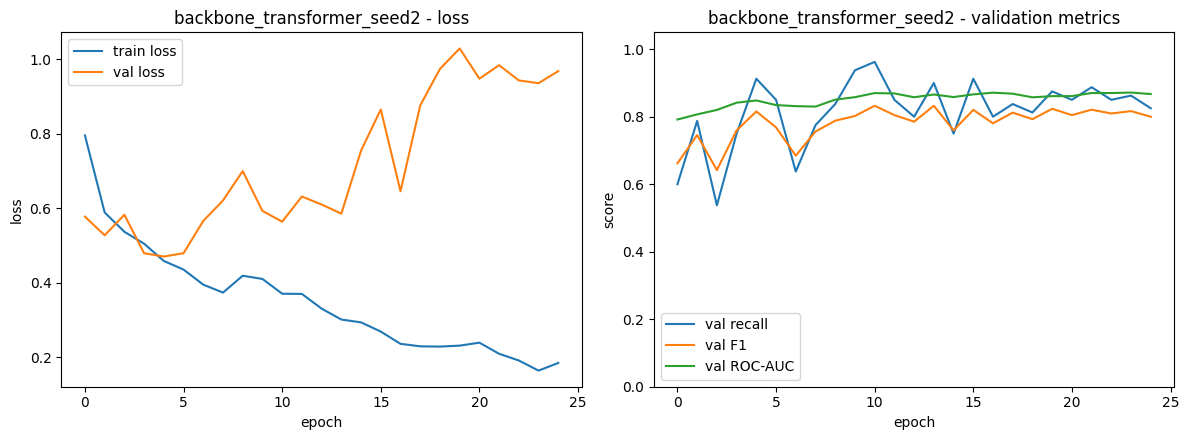

In [14]:
histories = {}
for name, run in experiment_results.items():
    histories[name] = load_history(run["config"].paths.log_dir, run["config"].paths.experiment_name)
    plot_training_curves(histories[name], title=name)

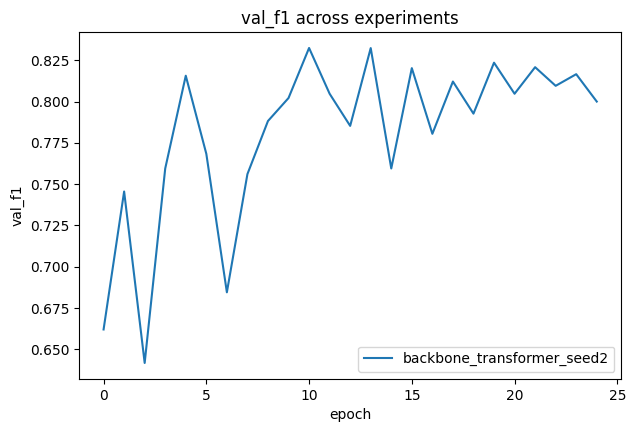

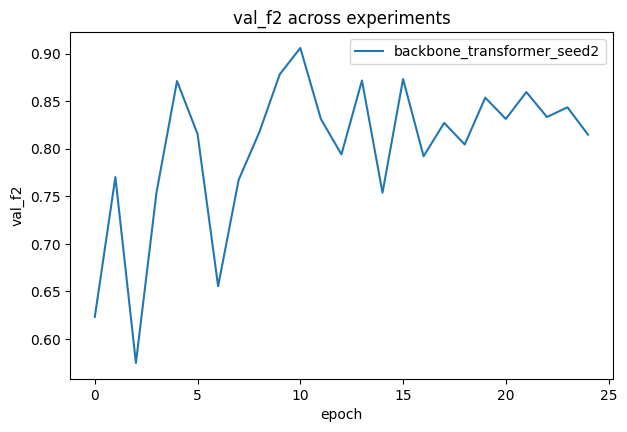

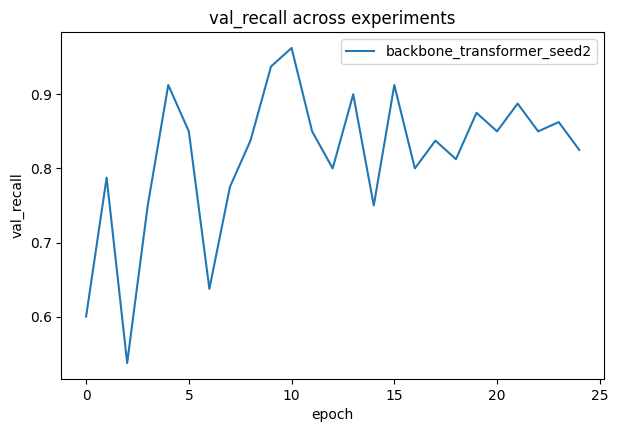

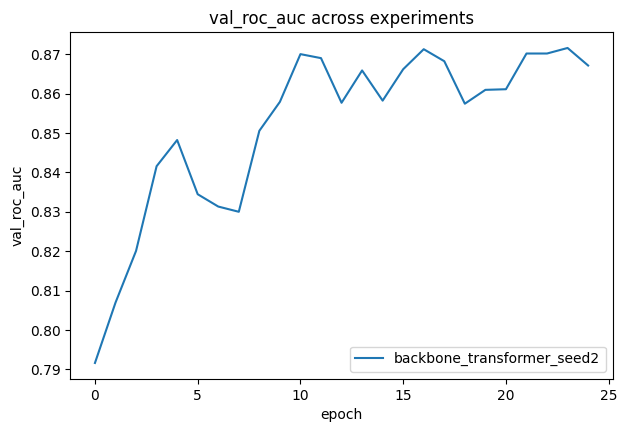

In [15]:
for metric_key in ["val_f1", "val_f2", "val_recall", "val_roc_auc"]:
    plot_comparison(histories, metric_key=metric_key)

## 14. Validation results

Each experiment's *best* epoch (by its own `monitor_metric`), not just its last one - the last epoch isn't always the best, e.g. under overfitting.

In [16]:
print(f"{'experiment':<28}{'best_epoch':<12}{'val_f1':<10}{'val_f2':<10}{'val_recall':<12}{'val_roc_auc':<12}")
for name, run in experiment_results.items():
    monitor_metric = run["config"].training.monitor_metric
    records = histories[name]
    best_record = max(records, key=lambda r: r[f"val_{monitor_metric}"])
    print(
        f"{name:<28}{best_record['epoch']:<12}"
        f"{best_record['val_f1']:<10.4f}{best_record['val_f2']:<10.4f}"
        f"{best_record['val_recall']:<12.4f}{best_record['val_roc_auc']:<12.4f}"
    )

experiment                  best_epoch  val_f1    val_f2    val_recall  val_roc_auc 
backbone_transformer_seed2  23          0.8166    0.8435    0.8625      0.8716      


## 15. Error analysis

Pick one experiment to dig into for the remaining sections. Runs the model over the validation split one clip at a time (rather than in shuffled batches) so each prediction can be traced back to its source file. For a large validation set, slice `val_samples[:200]` first to keep this quick.

In [17]:
# INSPECT_EXPERIMENT = "lightweight_tsm_run1"  # any key from EXPERIMENTS above

# config = experiment_results[INSPECT_EXPERIMENT]["config"]
# model = experiment_results[INSPECT_EXPERIMENT]["model"]
# test_loader = experiment_results[INSPECT_EXPERIMENT]["test_loader"]
# eval_transform = ClipEvalTransform(config.data.frame_size)
# _, val_samples, test_samples = build_sample_lists(config.data, config.training.seed)

# val_dataset_named = RWFVideoDataset(val_samples, config.data.num_frames, eval_transform, train=False)
# model.eval()
# predictions = []
# with torch.no_grad():
#     for i in range(len(val_dataset_named)):
#         clip, _ = val_dataset_named[i]
#         probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
#         path, true_label = val_samples[i]
#         predictions.append({"path": path, "label": true_label, "probability": probability})

# misclassified = [r for r in predictions if (r["probability"] >= 0.5) != bool(r["label"])]
# missed_fights = [r for r in misclassified if r["label"] == 1]  # false negatives - the costly kind here
# misclassified.sort(key=lambda r: abs(r["probability"] - r["label"]), reverse=True)
# print(f"{len(misclassified)} / {len(predictions)} validation clips misclassified")
# print(f"Of these, {len(missed_fights)} are missed real fights (false negatives) - the ones to look at first.")
# for r in misclassified[:5]:
#     print(r)

## 16. Final evaluation

Test-set metrics (threshold 0.5) for **every** experiment, then a closer look at `INSPECT_EXPERIMENT`: its confusion matrix, plus the threshold `find_threshold_for_recall` suggests for hitting a target recall - useful since a missed real fight (false negative) is worse than a false alarm here, so it's often worth deliberately trading some precision for recall.

In [18]:
# import gc
# import torch
# from torch.utils.data import DataLoader

# for exp in ["backbone_transformer_run1c","backbone_transformer_run2c", "lightweight_tsm_run1c", "lightweight_tsm_run2c"]:
#     print(f"\n{'=' * 20} Evaluating {exp} {'=' *20}")
#     # Recupera la configurazione e il modello
#     # config = experiment_results[exp]["config"]
#     # model = experiment_results[exp]["model"]
#     # Recupera il run
#     run = experiment_results[exp]

#     # Vecchio loader
#     old_loader = run["test_loader"]

#     print("Vecchio loader:")
#     print("  batch_size :", old_loader.batch_size)
#     print("  num_workers:", old_loader.num_workers)
#     print("  pin_memory :", old_loader.pin_memory)

#     # Elimina eventuali riferimenti al vecchio loader/iterator
#     del old_loader
#     gc.collect()

#     # Ricrea il DataLoader in modalità "sicura"
#     safe_loader = DataLoader(
#         run["test_loader"].dataset,
#         batch_size=4,
#         shuffle=False,
#         num_workers=0,
#         pin_memory=False,
#         collate_fn=run["test_loader"].collate_fn,
#     )

#     # Valutazione
#     metrics = run_evaluation(
#         run["model"],
#         safe_loader,
#         device
#     )

#     print(metrics)

In [19]:
print(f"{'experiment':<28}{'test_f1':<10}{'test_f2':<10}{'test_recall':<12}{'test_roc_auc':<12}")
test_metrics_by_experiment = {}
for name, run in experiment_results.items():
    # if name == "lightweight_tsm_run2b":
        metrics = run_evaluation(run["model"], run["test_loader"], device)
        test_metrics_by_experiment[name] = metrics
        print(
            f"{name:<28}{metrics['f1']:<10.4f}{metrics['f2']:<10.4f}"
            f"{metrics['recall']:<12.4f}{metrics['roc_auc']:<12.4f}"
        )

experiment                  test_f1   test_f2   test_recall test_roc_auc


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████| 27/27 [01:13<00:00,  2.74s/it]

backbone_transformer_seed2  0.7888    0.7805    0.7750      0.8689      


In [20]:
test_metrics = test_metrics_by_experiment[INSPECT_EXPERIMENT]
print(f"{INSPECT_EXPERIMENT} at threshold 0.5:")
print(json.dumps({k: v for k, v in test_metrics.items() if k != "confusion_matrix"}, indent=2))

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(config.data.class_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(config.data.class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {INSPECT_EXPERIMENT} (threshold 0.5)")
plt.show()

NameError: name 'INSPECT_EXPERIMENT' is not defined

In [ ]:
TARGET_RECALL = 0.95  # e.g. "miss at most 5% of real fights"

y_true, y_prob = [], []
model.eval()
with torch.no_grad():
    for clips, labels in test_loader:
        probabilities = torch.sigmoid(model(clips.to(device))).cpu().numpy()
        y_true.append(labels.numpy())
        y_prob.append(probabilities)
y_true, y_prob = np.concatenate(y_true), np.concatenate(y_prob)

suggested_threshold = find_threshold_for_recall(y_true, y_prob, TARGET_RECALL)
recall_metrics = compute_binary_metrics(y_true, y_prob, threshold=suggested_threshold)
print(f"Suggested threshold for >= {TARGET_RECALL:.0%} recall: {suggested_threshold:.3f}")
print(json.dumps(recall_metrics, indent=2))

Suggested threshold for >= 95% recall: 0.193
{
  "accuracy": 0.775,
  "precision": 0.7037037037037037,
  "recall": 0.95,
  "f1": 0.8085106382978723,
  "f2": 0.8878504672897196,
  "roc_auc": 0.8900250000000001
}



==================== Evaluating backbone_transformer_run1c ====================
DEVICE on: cuda

backbone_transformer_run1c at threshold 0.5:
{
  "accuracy": 0.7975,
  "precision": 0.84,
  "recall": 0.735,
  "f1": 0.784,
  "f2": 0.7538461538461538,
  "roc_auc": 0.85815
}

Confusion matrix — threshold 0.5:
[[172  28]
 [ 53 147]]

Suggested threshold for >= 95% recall: 0.003

Metrics at suggested threshold:
{
  "accuracy": 0.71,
  "precision": 0.6418918918918919,
  "recall": 0.95,
  "f1": 0.7661290322580645,
  "f2": 0.8667883211678832,
  "roc_auc": 0.85815
}

Confusion matrix — threshold 0.003:
[[ 94 106]
 [ 10 190]]

================ COMPARISON ================
Threshold 0.500     | Recall = 0.7350
Threshold 0.003   | Recall = 0.9500

==================== Evaluating backbone_transformer_run2c ====================
DEVICE on: cuda


/home/pp26/miniconda3/envs/pt/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



backbone_transformer_run2c at threshold 0.5:
{
  "accuracy": 0.775,
  "precision": 0.7925531914893617,
  "recall": 0.745,
  "f1": 0.7680412371134021,
  "f2": 0.7540485829959515,
  "roc_auc": 0.8722375
}

Confusion matrix — threshold 0.5:
[[161  39]
 [ 51 149]]

Suggested threshold for >= 95% recall: 0.004

Metrics at suggested threshold:
{
  "accuracy": 0.7675,
  "precision": 0.6959706959706959,
  "recall": 0.95,
  "f1": 0.8033826638477801,
  "f2": 0.8853681267474371,
  "roc_auc": 0.8722375
}

Confusion matrix — threshold 0.004:
[[117  83]
 [ 10 190]]

================ COMPARISON ================
Threshold 0.500     | Recall = 0.7450
Threshold 0.004   | Recall = 0.9500

==================== Evaluating lightweight_tsm_run1c ====================
DEVICE on: cuda

lightweight_tsm_run1c at threshold 0.5:
{
  "accuracy": 0.8275,
  "precision": 0.8393782383419689,
  "recall": 0.81,
  "f1": 0.8244274809160306,
  "f2": 0.8157099697885196,
  "roc_auc": 0.8943
}

Confusion matrix — threshold 0.5

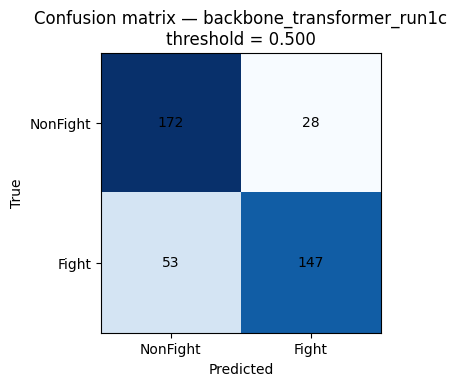

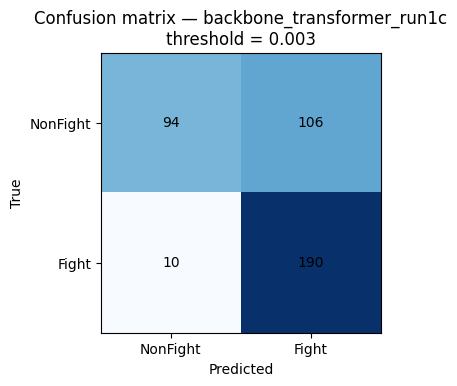

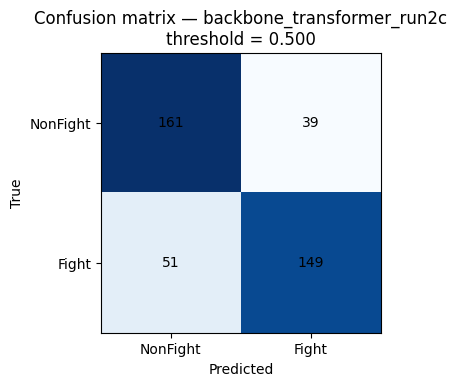

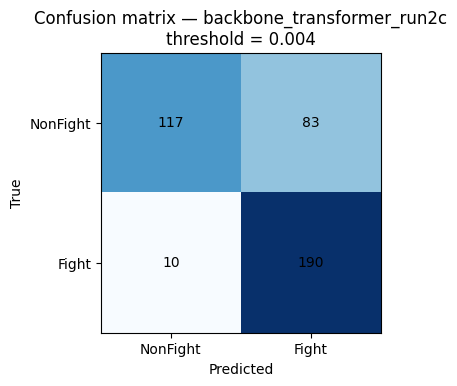

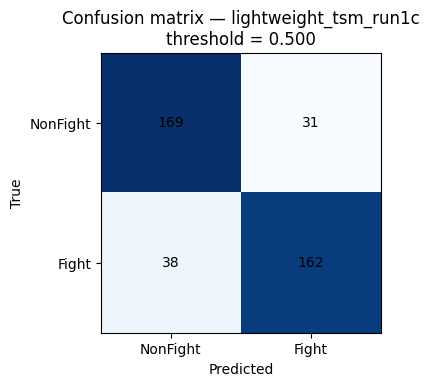

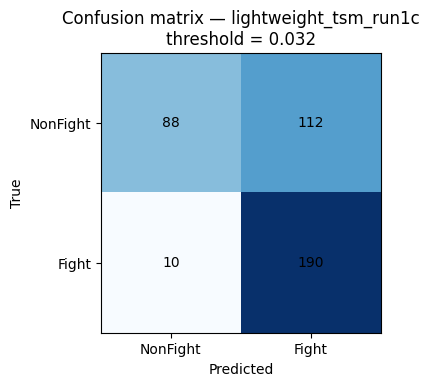

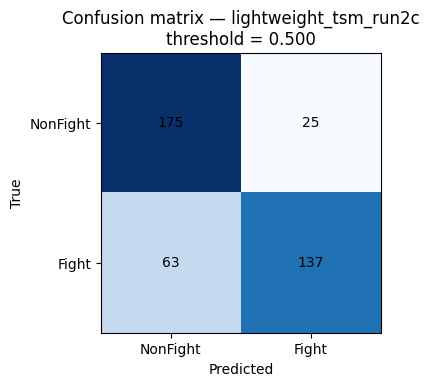

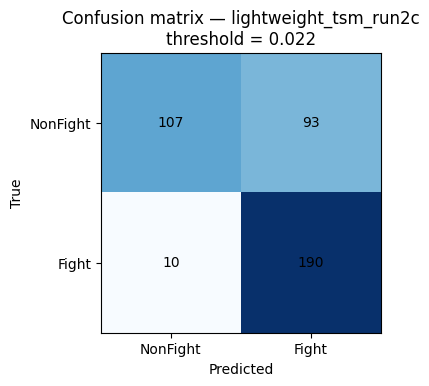

In [ ]:
import gc
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

for exp in ["backbone_transformer_run1c", "backbone_transformer_run2c", "lightweight_tsm_run1c", "lightweight_tsm_run2c"]:
    print(f"\n{'=' * 20} Evaluating {exp} {'=' *20}")
    # ============================================================
    # CONFIG
    # ============================================================

    INSPECT_EXPERIMENT = exp
    TARGET_RECALL = 0.95

    # Pulizia eventuale memoria già occupata
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


    # ============================================================
    # LOAD CONFIG FROM FILE
    # ============================================================

    config = Config.load(
        f"logs/{INSPECT_EXPERIMENT}/config.json"
    )

    set_seed(config.training.seed)


    # ============================================================
    # REBUILD TEST LOADER FROM CONFIG
    # ============================================================

    _, _, original_test_loader = build_dataloaders(config)

    # print("Original test loader:")
    # print("  batch_size :", original_test_loader.batch_size)
    # print("  num_workers:", original_test_loader.num_workers)
    # print("  pin_memory :", original_test_loader.pin_memory)


    # Creiamo un DataLoader sicuro per evitare problemi CUDA/pin_memory
    test_loader = DataLoader(
        original_test_loader.dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=original_test_loader.collate_fn,
    )


    # ============================================================
    # LOAD MODEL
    # ============================================================

    device = get_device()
    print("DEVICE on:", device)
    model = build_model(config).to(device)

    load_checkpoint(
        f"checkpoints/{INSPECT_EXPERIMENT}/last.pt",
        model,
        map_location=device
    )

    model.eval()


    # ============================================================
    # INFERENCE
    # ============================================================

    y_true = []
    y_prob = []

    with torch.no_grad():

        for clips, labels in test_loader:

            clips = clips.to(device)

            logits = model(clips)

            # Logit -> P(Fight)
            probabilities = torch.sigmoid(logits)

            # Assicura vettori 1D
            y_prob.append(
                probabilities.detach().cpu().numpy().reshape(-1)
            )

            y_true.append(
                labels.detach().cpu().numpy().reshape(-1)
            )


    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)

    # print(f"\nNumber of test samples: {len(y_true)}")


    # ============================================================
    # METRICS AT THRESHOLD 0.5
    # ============================================================

    test_metrics = compute_binary_metrics(
        y_true,
        y_prob,
        threshold=0.5
    )

    print(
        f"\n{INSPECT_EXPERIMENT} at threshold 0.5:"
    )

    print(
        json.dumps(test_metrics, indent=2)
    )


    # ============================================================
    # CONFUSION MATRIX - THRESHOLD 0.5
    # ============================================================

    pred_05 = (y_prob >= 0.5).astype(int)

    cm_05 = confusion_matrix(
        y_true,
        pred_05,
        labels=[0, 1]
    )

    print("\nConfusion matrix — threshold 0.5:")
    print(cm_05)


    fig, ax = plt.subplots(figsize=(4, 4))

    ax.imshow(cm_05, cmap="Blues")

    for (i, j), value in np.ndenumerate(cm_05):
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(config.data.class_names)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(config.data.class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_title(
        f"Confusion matrix — {INSPECT_EXPERIMENT}\n"
        f"threshold = 0.500"
    )

    plt.tight_layout()
    # plt.show()


    # ============================================================
    # FIND SUGGESTED THRESHOLD
    # ============================================================

    suggested_threshold = find_threshold_for_recall(
        y_true,
        y_prob,
        TARGET_RECALL
    )

    print(
        f"\nSuggested threshold for >= "
        f"{TARGET_RECALL:.0%} recall: "
        f"{suggested_threshold:.3f}"
    )


    # ============================================================
    # METRICS AT SUGGESTED THRESHOLD
    # ============================================================

    recall_metrics = compute_binary_metrics(
        y_true,
        y_prob,
        threshold=suggested_threshold
    )

    print(
        "\nMetrics at suggested threshold:"
    )

    print(
        json.dumps(recall_metrics, indent=2)
    )


    # ============================================================
    # CONFUSION MATRIX - SUGGESTED THRESHOLD
    # ============================================================

    pred_suggested = (
        y_prob >= suggested_threshold
    ).astype(int)

    cm_suggested = confusion_matrix(
        y_true,
        pred_suggested,
        labels=[0, 1]
    )

    print(
        f"\nConfusion matrix — threshold "
        f"{suggested_threshold:.3f}:"
    )

    print(cm_suggested)


    fig, ax = plt.subplots(figsize=(4, 4))

    ax.imshow(cm_suggested, cmap="Blues")

    for (i, j), value in np.ndenumerate(cm_suggested):
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(config.data.class_names)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(config.data.class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_title(
        f"Confusion matrix — {INSPECT_EXPERIMENT}\n"
        f"threshold = {suggested_threshold:.3f}"
    )

    plt.tight_layout()
    # plt.show()


    # ============================================================
    # DIRECT COMPARISON
    # ============================================================

    print("\n================ COMPARISON ================")

    print(
        f"Threshold 0.500     | "
        f"Recall = {test_metrics['recall']:.4f}"
    )

    print(
        f"Threshold {suggested_threshold:.3f}   | "
        f"Recall = {recall_metrics['recall']:.4f}"
    )

## 17. Example predictions

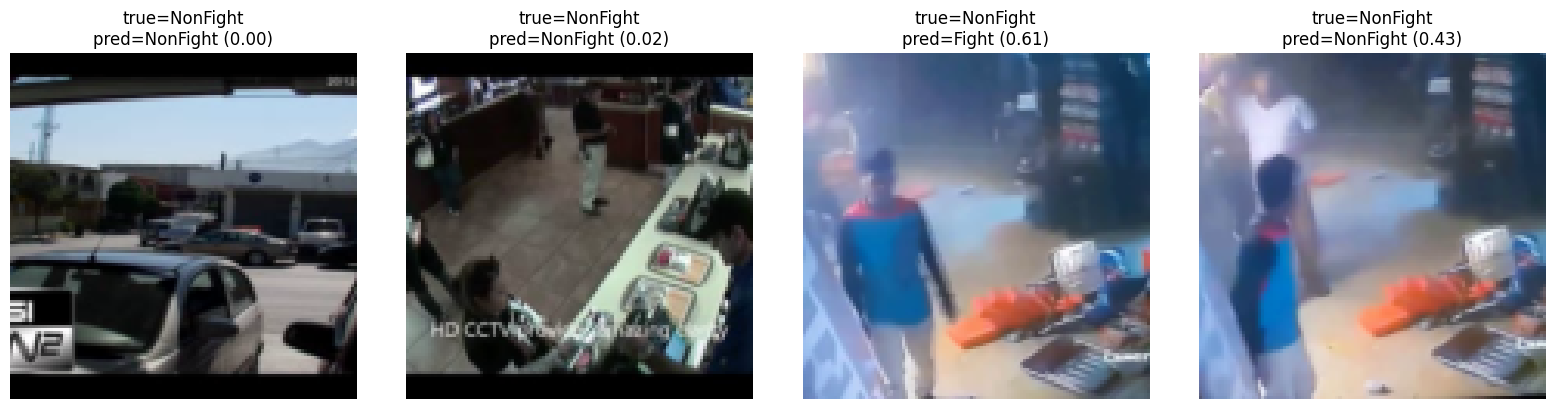

In [ ]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

n_examples = min(4, len(test_samples))
fig, axes = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))
for ax, (path, true_label) in zip(np.array(axes).flat, test_samples[:n_examples]):
    single = RWFVideoDataset([(path, true_label)], config.data.num_frames, eval_transform, train=False)
    clip, _ = single[0]
    with torch.no_grad():
        probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
    middle_frame = (clip[len(clip) // 2] * std + mean).clamp(0, 1)
    ax.imshow(middle_frame.permute(1, 2, 0).numpy())
    predicted = config.data.class_names[int(probability >= 0.5)]
    ax.set_title(f"true={config.data.class_names[true_label]}\npred={predicted} ({probability:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 18. Model checkpoint loading

In [ ]:
best_checkpoint_path = f"{config.paths.checkpoint_dir}/{config.paths.experiment_name}/best.pt"
reloaded_model = build_model(config).to(device)
checkpoint_info = load_checkpoint(best_checkpoint_path, reloaded_model, map_location=device)
print("Loaded checkpoint from epoch:", checkpoint_info["epoch"], "| best_metric:", checkpoint_info["best_metric"])

Loaded checkpoint from epoch: 12 | best_metric: 0.8518518518518519


## 19. Inference examples

In [ ]:
detector = ViolenceDetector(best_checkpoint_path, device=device)
example_path, example_label = test_samples[0]
prediction = detector.predict(example_path)
print("Ground truth:", config.data.class_names[example_label])
print("Prediction:", prediction)

Ground truth: NonFight
Prediction: {'label': 'NonFight', 'probability': 0.04888968914747238, 'threshold': 0.5}


## 20. Conclusions

_Summarise your findings here once you have real training runs to compare, e.g.:_

- Final test accuracy / F1 / F2 / recall / ROC-AUC for every experiment (§14, §16).
- Which configuration trained faster and which reached a higher ceiling.
- Whether any `backbone_transformer` variant showed train/val loss divergence (overfitting), and whether `unfreeze_num_stages=1` / extra dropout / weight decay helped.
- The precision/recall trade-off at your chosen threshold (§16) - is missing a real fight (false negative) or a false alarm (false positive) more costly for your use case?
- Recurring patterns in the misclassified clips from §15 (lighting, crowd density, camera motion, ...).
- Next steps: more augmentation, a different frame count, ensembling several experiments, etc.